In [794]:
import pandas as pd
import matplotlib.pyplot as plt 

In [795]:
df=pd.read_csv('S:\Coding\myproject\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [796]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [797]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [798]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [799]:
## duplicates
df.duplicated().sum()

0

In [800]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [801]:
num_cols=df.select_dtypes(include=["number"])

In [802]:
#-1- strong negative   1- strong positive


num_cols.corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


In [803]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [804]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Text(0.5, 1.0, 'churn (yes/no)')

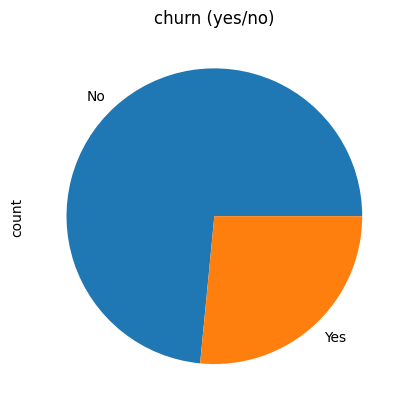

In [805]:
df["Churn"].value_counts().plot(kind='pie') 
plt.title("churn (yes/no)")

In [806]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [807]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [808]:
df.groupby(["Churn","gender"])["MonthlyCharges"].mean()

Churn  gender
No     Female    61.664908
       Male      60.876914
Yes    Female    74.812087
       Male      74.066989
Name: MonthlyCharges, dtype: float64

In [809]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [810]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [811]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [812]:
df.groupby("Contract")["MonthlyCharges"].mean()

Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64

#### at the lower terms wea can see that the monthly charge average decrease

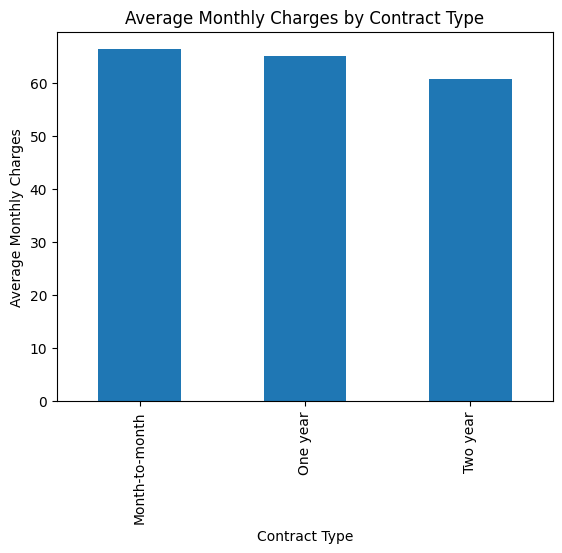

In [813]:
df.groupby("Contract")["MonthlyCharges"].mean().plot(kind='bar')
plt.title("Average Monthly Charges by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Average Monthly Charges")
plt.show()

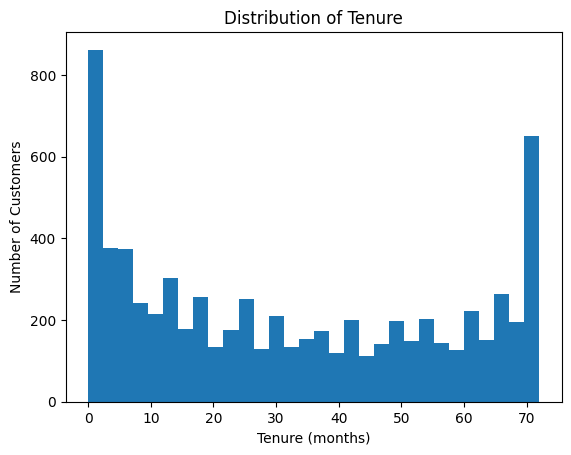

In [814]:
plt.hist(df["tenure"], bins=30)
plt.title("Distribution of Tenure") 
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")   
plt.show()

In [815]:
df.head(2)
#df["SeniorCitizen"].value_counts() 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


## Feature Engineering:-  
the process of transforming raw data into input features that can be used to train machine learning models

In [816]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [817]:
y = df["Churn"]# y is not a DataFrame — it’s a Series. Because we are selecting a single column.
x = df[["gender","tenure", "MonthlyCharges" ]] # x is a DataFrame

In [818]:
print(type(y)) #Series
type(x)



<class 'pandas.core.series.Series'>


pandas.core.frame.DataFrame

In [819]:
y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [820]:
x["gender_original"] = x["gender"].copy()

In [821]:
# x["gender"].apply(lambda v: 1 if v=="Female" else 0)  this will not change the original column    
x["gender"] = x["gender"].apply(lambda v: 1 if v=="Female" else 0) 

In [822]:
x["gender"].value_counts()

gender
0    3555
1    3488
Name: count, dtype: int64

In [823]:
type(x["gender"][0])

numpy.int64

In [824]:
y_original = y.copy()

In [825]:
y_original

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [826]:
y_original = y_original.apply(lambda x: 1 if x == "Yes" else 0)

In [827]:
y_original



0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [828]:
# y["Churn"].value_counts() error because y is a Series not a DataFrame
y_original.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [829]:
x.drop(columns=["gender_original"], inplace=True)

In [830]:
x



,gender,tenure,MonthlyCharges
0,1,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,1,2,70.70
...,...,...,...
7038,0,24,84.80
7039,1,72,103.20
7040,1,11,29.60
7041,0,4,74.40


In [831]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y_original, test_size=0.2,)

In [832]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [833]:
x_train = scaler.fit_transform(x_train)

In [834]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [835]:
x_test = scaler.fit_transform(x_test)

In [836]:
from sklearn.metrics import accuracy_score ,roc_auc_score

def modelperformance(predicted, probability):
    print("Accuracy score on model is {}".format(accuracy_score(y_test, predicted)))
    print("ROC AUC score on model is {}".format(roc_auc_score(y_test, probability)))
   

In [837]:
from sklearn.model_selection import GridSearchCV

## LogisticRegression

In [838]:
from sklearn.linear_model import LogisticRegression
log_model =LogisticRegression()

In [839]:
# if warning occurs 
import warnings 
warnings.filterwarnings('ignore') 

In [840]:
log_model.fit(x_train, y_train)

LogisticRegression()

In [841]:
x

,gender,tenure,MonthlyCharges
0,1,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,1,2,70.70
...,...,...,...
7038,0,24,84.80
7039,1,72,103.20
7040,1,11,29.60
7041,0,4,74.40


In [842]:
y_pred = log_model.predict(x_test)
y_prob = log_model.predict_proba(x_test)[:,1]

In [843]:
modelperformance(y_pred, y_prob)

Accuracy score on model is 0.7814052519517388
ROC AUC score on model is 0.8015926551461349


##  KNeighborsClassifier

In [844]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()

In [845]:
para_grid = {'n_neighbors': [3,5,7,9], 'weights': ['uniform', 'distance']}
## hyperparameter tuning

In [846]:
grid_search = GridSearchCV(knn_model, para_grid, cv=5)


In [847]:
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [848]:
grid_search.best_params_

{'n_neighbors': 7, 'weights': 'uniform'}

In [849]:
y_pred = grid_search.predict(x_test)
y_prob = grid_search.predict_proba(x_test)[:,1]

In [850]:
modelperformance(y_pred, y_prob)

Accuracy score on model is 0.7665010645848119
ROC AUC score on model is 0.7773732775843957


## svm

In [851]:
from sklearn.svm import SVC

In [852]:
svm = SVC()
## hyperparameter tuning for SVM


In [853]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly']}

In [854]:
para_grid = GridSearchCV(svm, param_grid, cv=5)

In [855]:
para_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10],
                         'kernel': ['linear', 'rbf', 'poly']})

In [856]:
para_grid.best_params_

{'C': 1, 'kernel': 'poly'}

In [857]:
y_pred = grid_search.predict(x_test)
y_prob = grid_search.predict_proba(x_test)[:,1]

In [858]:
modelperformance(y_pred, y_prob)

Accuracy score on model is 0.7665010645848119
ROC AUC score on model is 0.7773732775843957


##  decision tree classifier

In [859]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()

In [860]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None,10,20,30],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'splitter':['best','random']
}

In [861]:
grid_tree = GridSearchCV(dt_model, param_grid, cv=5)

In [862]:
grid_tree.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [863]:
y_pred = grid_tree.predict(x_test)
y_prob = grid_tree.predict_proba(x_test)[:,1]

In [864]:
modelperformance(y_pred,y_prob)

Accuracy score on model is 0.758694109297374
ROC AUC score on model is 0.7727814566126341


## rsndom forest

In [865]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()

In [866]:
param_grid = {
    'n_estimators': [32,64,128,256],
    'max_features': [2,3,4],
    'bootstrap': [True, False]
}

In [867]:
grid_rfc = GridSearchCV(rf_model, param_grid, cv=5)

In [868]:
grid_rfc.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 128, 256]})

In [869]:
y_pred = grid_rfc.predict(x_test)
y_prob = grid_rfc.predict_proba(x_test)[:,1]

In [870]:
modelperformance(y_pred, y_prob)

Accuracy score on model is 0.7537260468417317
ROC AUC score on model is 0.7538876645177237


In [871]:
## best_model = log_model.best_estimator_ 
# joblib.dump(best_model, "churn_model.pkl")   not work for logixstic regression beause log_model is not a GridSearchCV object.

In [872]:
## so we use directly
joblib.dump(log_model, "churn_model.pkl")

['churn_model.pkl']

In [873]:
x.columns

Index(['gender', 'tenure', 'MonthlyCharges'], dtype='object')

## XGBoost

```markdown
## XGBoost

XGBoost (eXtreme Gradient Boosting) is a powerful machine learning algorithm based on gradient boosting. It's highly effective for classification and regression tasks. In this section, we'll implement XGBoost for customer churn prediction and perform hyperparameter tuning using GridSearchCV to optimize model performance.
```

In [874]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)

param_dist = {
    "n_estimators": [300, 500, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.05, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2]
}

grid_xgb = GridSearchCV(xgb_model, param_grid, cv=5)
grid_xgb.fit(x_train, y_train)

print("Best parameters:", grid_xgb.best_params_)

y_pred = grid_xgb.predict(x_test)
y_prob = grid_xgb.predict_proba(x_test)[:,1]
modelperformance(y_pred, y_prob)

Best parameters: {'bootstrap': True, 'max_features': 2, 'n_estimators': 32}
Accuracy score on model is 0.7750177430801988
ROC AUC score on model is 0.7976110172807976
